# 🏛️ Comitê Multiagente: Debate Estrutural da Economia Brasileira

Sistema que usa Inteligência Artificial como motor de raciocínio crítico em cadeia para simular um comitê de política econômica. O pipeline analisa dados macroeconômicos reais do Brasil — usando EUA e China apenas como contexto exógeno — para produzir recomendações de política pública tecnicamente sólidas e politicamente viáveis.

## 🗺️ Roadmap deste projeto

Este notebook é a **v1**. O plano de evolução é público e intencional:

| Versão | Status | O que inclui |
|---|---|---|
| **v1** | ✅ Este notebook | 3 agentes em cadeia (Economista → Crítico → Ministro), dados de PIB e Inflação (Brasil, EUA, China), relatório final + histórico de execuções |
| **v2** | 🔜 Próximo post | Novos dados (Câmbio, Desemprego, Selic, Dívida/PIB) e um teste de robustez: injetar um dado incoerente na tabela e medir se o Revisor Crítico detecta a inconsistência |
| **v3** | 🔭 Pesquisa futura | Agente extra de Red Team (tenta derrubar a decisão final), backtesting histórico (comparar recomendação passada com o que realmente aconteceu) e um score de consenso entre os agentes, plotável ao longo do tempo |
| **v4** | ⚖️ Teste de Integridade | Estresse de persona (economia comportamental): injetar no prompt do Ministro dilemas éticos, pressão de reeleição ou crises financeiras pessoais fictícias, e medir o quanto a decisão final se desvia da recomendação racional-base — um teste sobre o agente manter a racionalidade de Estado ou ceder à corrupção |
---


## 1. Coleta de Dados

Extração automatizada via API do Banco Mundial (`wbgapi`) dos indicadores de PIB e Inflação para Brasil, EUA e China, cobrindo a última década.

In [1]:
!pip install wbgapi -q

import wbgapi as wb
import pandas as pd
from datetime import datetime

PAISES = ['BRA', 'USA', 'CHN']

INDICADORES = {
    'NY.GDP.MKTP.KD.ZG': 'PIB',
    'FP.CPI.TOTL.ZG': 'Inflacao'
}

ANO_FIM = datetime.now().year - 1
ANO_INICIO = ANO_FIM - 9

def extrair_indicador(codigo_indicador, nome_coluna):
    """
    Busca um indicador do Banco Mundial para os PAISES e o intervalo de anos
    definidos acima, e devolve um DataFrame "longo" (uma linha por país/ano).
    """

    df_bruto = wb.data.DataFrame(
        codigo_indicador,
        economy=PAISES,
        time=range(ANO_INICIO, ANO_FIM + 1),
        labels=True
    )

    df_bruto = df_bruto.reset_index()

    df_longo = df_bruto.melt(
        id_vars=['economy', 'Country'],
        var_name='Ano_raw',
        value_name=nome_coluna
    )

    df_longo['Ano'] = df_longo['Ano_raw'].str.replace('YR', '', regex=False).astype(int)

    df_longo = df_longo.rename(columns={'Country': 'Pais'})
    df_longo = df_longo[['Pais', 'Ano', nome_coluna]]

    return df_longo

df_pib = extrair_indicador('NY.GDP.MKTP.KD.ZG', 'PIB')
df_inflacao = extrair_indicador('FP.CPI.TOTL.ZG', 'Inflacao')

df_final = pd.merge(df_pib, df_inflacao, on=['Pais', 'Ano'], how='inner')

df_final = df_final.dropna(subset=['PIB', 'Inflacao'])

df_final['PIB'] = df_final['PIB'].round(2)
df_final['Inflacao'] = df_final['Inflacao'].round(2)

df_final = df_final.sort_values(by=['Pais', 'Ano']).reset_index(drop=True)

print(f"Dados extraídos: {ANO_INICIO} a {ANO_FIM}")
print(f"Total de linhas: {len(df_final)}\n")
display(df_final)

Dados extraídos: 2016 a 2025
Total de linhas: 29



,Pais,Ano,PIB,Inflacao
0,Brazil,2016,-3.28,8.74
1,Brazil,2017,1.32,3.45
2,Brazil,2018,1.78,3.66
3,Brazil,2019,1.22,3.73
4,Brazil,2020,-3.28,3.21
5,Brazil,2021,4.76,8.30
6,Brazil,2022,3.02,9.28
7,Brazil,2023,3.24,4.59
8,Brazil,2024,3.42,4.37
9,Brazil,2025,2.29,5.02


## 2. Panorama Visual: Brasil, EUA e China

Antes de qualquer IA entrar em cena, vale olhar os dados brutos: como PIB e inflação se comportaram nos três países na última década.

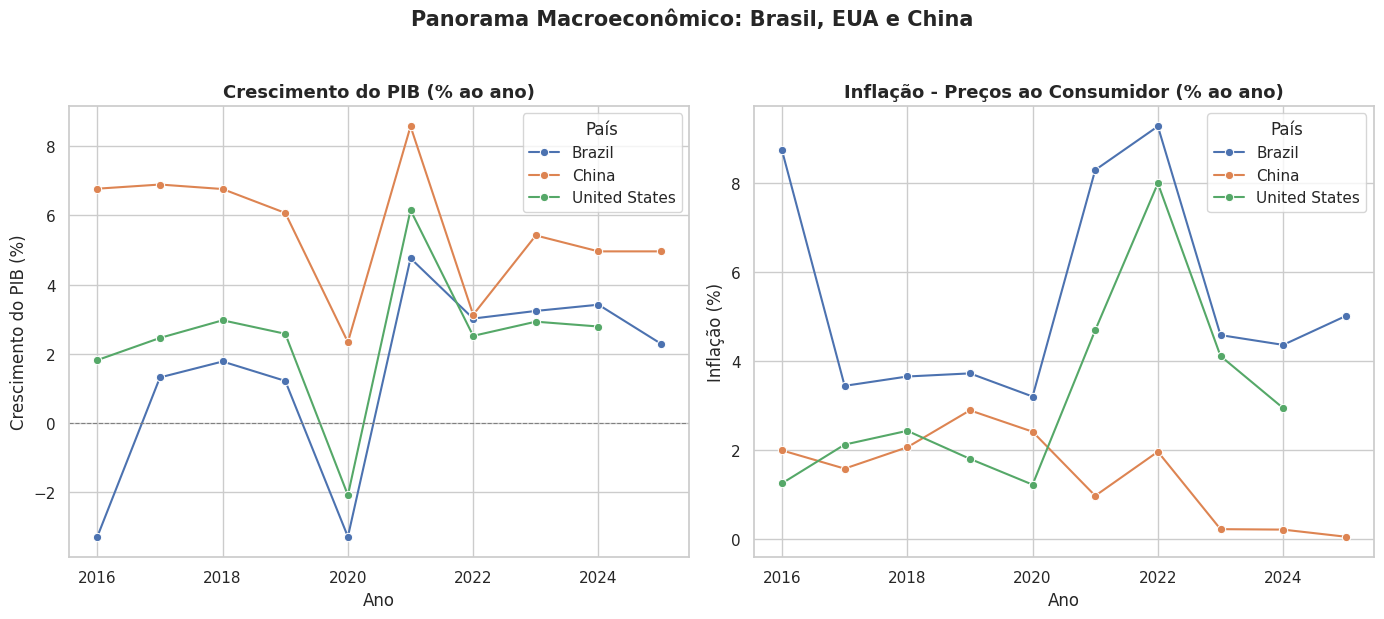

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

paleta_paises = sns.color_palette("deep", n_colors=df_final['Pais'].nunique())

fig, eixos = plt.subplots(1, 2, figsize=(14, 6))

sns.lineplot(
    data=df_final,
    x='Ano',
    y='PIB',
    hue='Pais',
    marker='o',
    palette=paleta_paises,
    ax=eixos[0]
)

eixos[0].set_title('Crescimento do PIB (% ao ano)', fontsize=13, fontweight='bold')
eixos[0].set_xlabel('Ano')
eixos[0].set_ylabel('Crescimento do PIB (%)')

eixos[0].axhline(0, color='gray', linewidth=0.8, linestyle='--')

eixos[0].legend(title='País', loc='best')

sns.lineplot(
    data=df_final,
    x='Ano',
    y='Inflacao',
    hue='Pais',
    marker='o',
    palette=paleta_paises,
    ax=eixos[1]
)

eixos[1].set_title('Inflação - Preços ao Consumidor (% ao ano)', fontsize=13, fontweight='bold')
eixos[1].set_xlabel('Ano')
eixos[1].set_ylabel('Inflação (%)')
eixos[1].legend(title='País', loc='best')

fig.suptitle('Panorama Macroeconômico: Brasil, EUA e China', fontsize=15, fontweight='bold', y=1.03)

plt.tight_layout()

plt.show()

## 3. Configuração do Comitê

Autenticação na API do Gemini e preparação da tabela de dados que será enviada como contexto para os três agentes.

In [3]:
import os
from getpass import getpass

if not os.environ.get("GEMINI_API_KEY"):
    try:
        from google.colab import userdata
        os.environ["GEMINI_API_KEY"] = userdata.get("GEMINI_API_KEY")
    except Exception:
        os.environ["GEMINI_API_KEY"] = getpass("Cole sua GEMINI_API_KEY aqui: ")

In [4]:
!pip install -U google-genai -q

import os
from google import genai
from google.genai import types
from IPython.display import display, Markdown

API_KEY = os.environ["GEMINI_API_KEY"]

client = genai.Client(api_key=API_KEY)

dados_em_texto = df_final.to_string(index=False)


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.4/56.4 kB 670.2 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 258.6/258.6 kB 8.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires google-auth==2.49.0, but you have google-auth 2.56.2 which is incompatible.


## 4. O Comitê em Ação

Aqui roda o debate completo: o **Economista Chefe** propõe um diagnóstico, o **Revisor Crítico** audita a viabilidade política, e o **Ministro da Fazenda** arbitra a decisão final. As três chamadas são encadeadas dentro de `rodar_pipeline_multiagente()`, com temperaturas diferentes por papel (0.3 → 0.4 → 0.2).

In [5]:
def rodar_pipeline_multiagente(dados_em_texto, client, modelo="gemini-3.5-flash", verbose=True):
    """
    Executa o pipeline completo do sistema multi-agentes:
      Etapa 3 -> Economista Chefe   (propõe um diagnóstico + recomendações)
      Etapa 4 -> Revisor Crítico    (audita viabilidade política/social)
      Etapa 5 -> Ministro (síntese) (arbitra e decide)

    Parâmetros:
        dados_em_texto (str): tabela do df_final já convertida em texto.
        client (genai.Client): cliente já autenticado da API Gemini.
        modelo (str): nome do modelo a ser usado em todas as 3 chamadas.
        verbose (bool): se True, imprime o progresso de cada etapa no console.

    Retorna:
        dict com as 3 respostas de texto:
            {
                "economista": <str>,
                "critico": <str>,
                "sintese": <str>
            }
    """

    if verbose:
        print("[1/3] Gerando relatório do Economista Chefe...")

    system_prompt_economista = """
    Você é o Economista Chefe do Brasil.

    PERSONA:
    - Seu foco é inteiramente a estabilidade e o crescimento da economia
      brasileira. Seu tom é frio, racional e pragmático.

    COMO USAR OS DADOS FORNECIDOS:
    - Os dados de PIB e Inflação do BRASIL são o objeto central da sua
      análise. Trace a trajetória da última década.
    - Os dados dos ESTADOS UNIDOS e da CHINA devem ser tratados apenas como
      variáveis exógenas (choques externos), nunca como economias
      independentes analisadas por si só.

    ESTRUTURA OBRIGATÓRIA (em Markdown):
    1. Diagnóstico da saúde macroeconômica brasileira na última década.
    2. Seção final "Conclusão Pragmática", com recomendações concretas de
       política econômica.

    Responda sempre em português do Brasil.
    """

    prompt_economista = f"""
    Tabela de dados macroeconômicos (Pais, Ano, PIB, Inflacao):
    {dados_em_texto}

    Produza o relatório solicitado, seguindo rigorosamente sua persona.
    """

    resposta_economista = client.models.generate_content(
        model=modelo,
        contents=prompt_economista,
        config=types.GenerateContentConfig(
            system_instruction=system_prompt_economista,
            temperature=0.3
        )
    )

    if verbose:
        print("[2/3] Gerando parecer do Revisor Crítico...")

    system_prompt_critico = """
    Você é o Revisor Crítico do Ministério da Fazenda do Brasil, especialista
    em Economia Institucional e Política. Seu trabalho é auditar o relatório
    do Economista Chefe. Avalie a viabilidade política e social das
    propostas dele (como o Congresso ou a rigidez orçamentária reagiriam).
    Aponte os efeitos colaterais de curto prazo (ex: desemprego, queda na
    indústria) das medidas de austeridade dele. Por fim, proponha
    alternativas mais pragmáticas e menos focadas apenas em corte de gastos.
    """

    prompt_critico = f"""
    RELATÓRIO A SER AUDITADO (produzido pelo Economista Chefe do Brasil):

    {resposta_economista.text}

    Com base apenas nesse relatório, produza seu parecer crítico, seguindo
    rigorosamente as diretrizes da sua persona.
    """

    resposta_critico = client.models.generate_content(
        model=modelo,
        contents=prompt_critico,
        config=types.GenerateContentConfig(
            system_instruction=system_prompt_critico,
            temperature=0.4
        )
    )

    if verbose:
        print("[3/3] Gerando decisão final do Ministro (síntese)...")

    system_prompt_arbitro = """
    Você é o Ministro da Fazenda do Brasil (ou o Tomador de Decisão Final).
    Seu trabalho é ler o relatório rigoroso do Economista Chefe e o
    contraponto do Revisor Crítico. Produza um Resumo Executivo final
    (máximo de 3 parágrafos e 3 bullet points de ação). O resumo deve ser a
    síntese perfeita: equilibrar a necessidade de responsabilidade fiscal
    com a realidade da rigidez orçamentária e estabilidade política. Seja
    decisivo, direto e pragmático.
    """

    prompt_arbitro = f"""
    RELATÓRIO DO ECONOMISTA:
    {resposta_economista.text}

    PARECER DO CRÍTICO:
    {resposta_critico.text}

    Escreva a decisão final.
    """

    resposta_arbitro = client.models.generate_content(
        model=modelo,
        contents=prompt_arbitro,
        config=types.GenerateContentConfig(
            system_instruction=system_prompt_arbitro,
            temperature=0.2
        )
    )

    if verbose:
        print("Pipeline concluído.\n")

    return {
        "economista": resposta_economista.text,
        "critico": resposta_critico.text,
        "sintese": resposta_arbitro.text
    }

resultado = rodar_pipeline_multiagente(dados_em_texto, client)

display(Markdown("## 🇧🇷 Relatório Original — Economista Chefe do Brasil"))
display(Markdown(resultado["economista"]))

display(Markdown("---"))
display(Markdown("## 🏛️ PARECER CRÍTICO - AVALIAÇÃO INSTITUCIONAL E POLÍTICA"))
display(Markdown(resultado["critico"]))

display(Markdown("---"))
display(Markdown("## 🔨 MARTELO BATIDO: RESUMO EXECUTIVO E DECISÃO FINAL"))
display(Markdown(resultado["sintese"]))

[1/3] Gerando relatório do Economista Chefe...
[2/3] Gerando parecer do Revisor Crítico...
[3/3] Gerando decisão final do Ministro (síntese)...
Pipeline concluído.



## 🇧🇷 Relatório Original — Economista Chefe do Brasil

# Diagnóstico da Saúde Macroeconômica Brasileira na Última Década (2016-2025)

A análise dos dados macroeconômicos do Brasil no período entre 2016 e 2025 revela uma trajetória de volatilidade estrutural, marcada por choques exógenos severos, lenta recuperação de crises internas e uma persistente dificuldade em conciliar crescimento sustentável com estabilidade de preços.

```
Brasil: Trajetória de PIB vs. Inflação (2016-2025)
   PIB (%)     Inflação (%)
2016 [ -3.28 ] [====== 8.74 ] (Recessão e inflação alta)
2017 [ = 1.32 ] [== 3.45 ]    (Desinflação e início de recuperação)
2018 [ == 1.78 ] [== 3.66 ]
2019 [ = 1.22 ] [== 3.73 ]    (Crescimento medíocre pré-pandemia)
2020 [ -3.28 ] [== 3.21 ]    (Choque pandêmico)
2021 [ ==== 4.76 ] [====== 8.30 ] (Retomada inflacionária)
2022 [ === 3.02 ] [======= 9.28 ] (Pico inflacionário)
2023 [ === 3.24 ] [=== 4.59 ]    (Resiliência com desinflação)
2024 [ === 3.42 ] [=== 4.37 ]
2025 [ == 2.29 ] [==== 5.02 ]   (Desaceleração e pressão inflacionária)
```

### 1. O Período de Ajuste e Baixo Crescimento (2016-2019)
O ponto de partida em 2016 reflete o esgotamento de uma matriz macroeconômica intervencionista, resultando em uma recessão profunda (PIB de -3,28%) combinada com inflação elevada (8,74%). O triênio subsequente (2017-2019) caracterizou-se por uma lenta recuperação cíclica, com o PIB orbitando a média medíocre de 1,44% ao ano. O aspecto positivo deste período foi a ancoragem temporária da inflação, que recuou para a casa dos 3,5%, permitindo uma flexibilização monetária que, contudo, não se traduziu em tração robusta na atividade econômica devido à fraqueza da demanda interna e incertezas fiscais.

### 2. O Choque Pandêmico e a Resposta Inflacionária (2020-2022)
Em 2020, a economia brasileira sofreu nova contração severa de -3,28%, reflexo direto das paralisações globais. A resposta de política econômica (estímulos fiscais e monetários agressivos), embora necessária para mitigar o colapso social, gerou desequilíbrios severos nos anos seguintes. 

O crescimento de 4,76% em 2021 e 3,02% em 2022 veio acompanhado de um violento choque inflacionário (8,30% e 9,28%, respectivamente). Esse fenômeno foi severamente agravado por vetores exógenos:
* **Choque de Liquidez e Cadeias Globais:** A forte expansão monetária nos Estados Unidos (cuja inflação saltou de 1,23% em 2020 para 8,00% em 2022) pressionou os preços globais de *commodities* e desorganizou cadeias de suprimentos.
* **Demanda Externa:** A resiliência da demanda chinesa por matérias-primas agrícolas e minerais (com o PIB da China crescendo 8,57% em 2021) sustentou as exportações brasileiras, mas pressionou os preços domésticos via taxa de câmbio e paridade de exportação.

### 3. Consolidação Recente e Sinais de Alerta (2023-2025)
O biênio 2023-2024 apresentou um desempenho de atividade superior às expectativas de mercado, registrando expansões de 3,24% e 3,42%, respectivamente, acompanhadas de uma convergência temporária da inflação para patamares próximos a 4,5%. 

No entanto, os dados projetados para 2025 acendem um sinal de alerta crítico: o crescimento desacelera para 2,29%, enquanto a inflação volta a acelerar para 5,02%, rompendo o teto da meta implícita de estabilidade. Este cenário de "estagflação moderada" reflete o esgotamento dos estímulos ao consumo, a persistência de indexadores na economia e a desconfiança dos agentes econômicos na sustentabilidade fiscal de longo prazo. O cenário externo também se torna menos favorável, com a desaceleração estrutural da China (estabilizada em 4,96% em 2024/2025) limitando o espaço para novos booms de *commodities*.

---

# Conclusão Pragmática

Para garantir a estabilidade macroeconômica e evitar que o Brasil retorne ao ciclo de baixo crescimento com inflação alta observado na projeção de 2025, as seguintes medidas de política econômica devem ser implementadas de forma imediata e rigorosa:

1. **Aperto Monetário Preventivo e Comunicação Firme:**
   Diante da projeção de inflação de 5,02% para 2025, o Banco Central do Brasil deve manter uma postura monetária restritiva (juros reais elevados). A autoridade monetária não deve hesitar em elevar a taxa Selic para ancorar as expectativas de inflação para o horizonte relevante de política monetária, neutralizando os efeitos de segunda ordem da depreciação cambial.

2. **Consolidação Fiscal Estrutural (Corte de Gastos Obrigatórios):**
   A política monetária restritiva perde eficácia se a política fiscal continuar expansionista. É imperativo substituir o foco exclusivo no aumento de receitas por um controle rígido das despesas correntes e indexações constitucionais. A meta deve ser a geração de superávits primários consistentes para estabilizar a relação Dívida/PIB, reduzindo o prêmio de risco país.

3. **Aumento da Produtividade e Abertura Comercial:**
   O crescimento potencial do PIB brasileiro é historicamente baixo. Para mitigar o impacto da desaceleração da China (variável exógena que limita nossa pauta exportadora tradicional), o Brasil precisa acelerar a agenda de reformas microeconômicas (simplificação tributária pós-reforma do consumo, desregulamentação de mercados e segurança jurídica para concessões de infraestrutura) para atrair investimento privado direto.

4. **Mitigação de Riscos Cambiais e Choques Externos:**
   Fortalecer a posição de reservas internacionais e utilizar instrumentos cambiais derivativos de forma cirúrgica para suavizar a volatilidade do Real frente ao Dólar, especialmente em períodos de aperto monetário nos Estados Unidos, evitando o repasse cambial (*pass-through*) para os preços domésticos.

---

## 🏛️ PARECER CRÍTICO - AVALIAÇÃO INSTITUCIONAL E POLÍTICA

# PARECER CRÍTICO INSTITUCIONAL
**De:** Revisor Crítico do Ministério da Fazenda  
**Para:** Ministro da Fazenda / Gabinete Extraordinário de Avaliação Macroeconômica  
**Assunto:** Auditoria Crítica do Relatório Decenal (2016-2025) do Economista-Chefe  

---

### Introdução: O Ponto Cego da Ortodoxia

O relatório apresentado pelo Economista-Chefe oferece uma descrição estatística precisa da volatilidade macroeconômica brasileira na última década. No entanto, ao formular suas recomendações de política econômica, o relatório incorre no clássico viés da ortodoxia insulada: **trata a economia como um sistema de equações lineares isolado da realidade política, social e institucional do país.**

As propostas de "ajuste imediato e rigoroso" ignoram a economia política do orçamento brasileiro, a rigidez constitucional e os limites da tolerância social à austeridade. Abaixo, apresento a auditoria crítica dessas medidas, apontando seus efeitos colaterais e propondo alternativas pragmáticas viáveis para o desenho de políticas públicas.

---

### 1. Viabilidade Política e Social das Propostas (A Realidade das Instituições)

O Economista-Chefe sugere um "controle rígido das despesas correntes e indexações constitucionais" e um "aperto monetário preventivo". Na arena política real, essas medidas enfrentam barreiras quase intransponíveis:

*   **A Ilusão do Corte de Gastos Obrigatórios via Decreto:** Cerca de 92% a 95% do Orçamento Geral da União (OGU) é composto por despesas obrigatórias (previdência, pessoal, assistência social e mínimos constitucionais de saúde e educação). Desvincular ou desindexar esses gastos exige Emendas à Constituição (PECs). 
*   **A Reação do Congresso Nacional:** O Congresso atual, altamente fragmentado e dependente do controle sobre o orçamento (via emendas impositivas e de comissão), não possui incentivos políticos para aprovar medidas impopulares de corte de gastos sociais, especialmente sob a justificativa abstrata de "ancoragem de expectativas". O custo político de aprovar tais reformas exigiria do Executivo uma liberação ainda maior de emendas parlamentares, anulando o esforço fiscal pretendido (o "paradoxo da barganha fiscal").
*   **Conflito Distributivo e Judicialização:** A desindexação do salário-mínimo sobre os benefícios previdenciários e assistenciais (como o BPC) geraria imediata reação de movimentos sociais e sindicatos, além de ser fatalmente judicializada no Supremo Tribunal Federal (STF) sob a tese da vedação ao retrocesso social.
*   **O Conflito Federativo:** Cortes em saúde e educação penalizam diretamente estados e municípios, que já operam no limite fiscal, transferindo a crise da União para os entes subnacionais e gerando paralisia nos serviços públicos básicos.

---

### 2. Efeitos Colaterais de Curto Prazo da Austeridade Proposta

A aplicação dogmática das recomendações do Economista-Chefe para 2025 ("aperto monetário preventivo" + "corte de gastos estruturais") produziria efeitos colaterais recessivos graves no curto prazo:

```
[Aperto Monetário + Corte de Gastos] 
       │
       ├─► (+) Custo do Crédito & (-) Investimento Público
       │         │
       │         └─► Queda na Indústria e Construção Civil ──► Desemprego
       │
       └─► (-) Transferências de Renda & (-) Consumo das Famílias
                 │
                 └─► Queda na Arrecadação Fiscal ──► Piora do Déficit (Fracasso do Ajuste)
```

*   **Asfixia da Indústria e da Construção Civil:** A elevação da taxa Selic encarece o crédito corporativo e o financiamento habitacional, setores altamente intensivos em mão de obra. O resultado imediato seria a interrupção da trajetória de recuperação do emprego formal.
*   **A "Armadilha da Austeridade" (Contração Fiscal Auto-derrotável):** Ao cortar investimentos públicos e contrair a demanda agregada em um momento de desaceleração (PIB projetado de 2,29% para 2025), o governo reduz a atividade econômica e, consequentemente, a arrecadação de tributos. O resultado líquido é a deterioração — e não a melhora — da relação Dívida/PIB.
*   **Inibição do Investimento Privado (*Crowding-out* de Infraestrutura):** O investimento privado no Brasil é complementar ao investimento público. Sem o aporte do Estado em infraestrutura logística e energética, o empresariado retrai seus planos de expansão, abortando o ganho de produtividade sugerido no relatório.

---

### 3. Alternativas Pragmáticas e Politicamente Viáveis

Para conciliar a responsabilidade fiscal com a estabilidade social e o crescimento, o Ministério da Fazenda deve adotar uma abordagem de **Economia Política Institucional**, focada em receitas inteligentes, coordenação macroeconômica e transição ecológica:

#### A. Otimização de Receitas e Combate aos Privilégios Fiscais (Justiça Tributária)
Em vez de focar exclusivamente no corte de serviços essenciais, o foco deve ser a **revisão dos gastos tributários (subsídios e isenções)**, que custam cerca de 4% do PIB ao ano.
*   *Medida:* Redução gradual e linear de 10% ao ano nos subsídios ineficientes concedidos a setores que não geram contrapartida em emprego ou inovação.
*   *Tributação Progressiva:* Implementação da taxação de super-ricos (fundos exclusivos e offshores) e reforma da tributação sobre a renda, compensando a perda de dinamismo do consumo.

#### B. Coordenação Institucional (Pacto Fiscal-Monetário)
A autoridade monetária e a autoridade fiscal não podem operar em direções opostas.
*   *Medida:* Estabelecer um canal de comunicação formal onde o Ministério da Fazenda se compromete com metas críveis de receitas extraordinárias e controle do crescimento real das despesas (dentro das regras do Arcabouço Fiscal), enquanto o Banco Central sinaliza uma trajetória de juros condizente com o custo de rolagem da dívida pública. Juros reais civilizados são o maior programa de corte de gastos do país.

#### C. Alavancagem de Investimentos via Parcerias e Transição Ecológica
Substituir o investimento público direto por mecanismos de garantia e atração de capital privado nacional e internacional.
*   *Medida:* Utilizar o **Plano de Transformação Ecológica** e a emissão de títulos soberanos sustentáveis (Green Bonds) para financiar a infraestrutura de baixo carbono.
*   *Neoindustrialização:* Direcionar o crédito do BNDES exclusivamente para inovação, transição energética e adensamento tecnológico da indústria nacional, evitando subsídios generalizados do passado, mas garantindo competitividade frente à desaceleração da China.

#### D. Reforma Administrativa Focada em Eficiência, não em Punição
Uma reforma que foque na modernização do Estado e na eliminação de supersalários e privilégios do topo do funcionalismo (judiciário, legislativo e alta cúpula militar), poupando os servidores da ponta (professores, policiais e médicos). Isso gera legitimidade política perante a opinião pública e economia fiscal real de médio prazo.

---

### Conclusão

O relatório do Economista-Chefe acerta no diagnóstico dos riscos de 2025, mas falha ao receitar remédios amargos que o paciente (a sociedade brasileira) não tem condições políticas de engolir. A estabilidade macroeconômica sustentável não será alcançada pela força da austeridade recessiva, mas sim pela **construção de consensos institucionais, justiça tributária e indução inteligente do investimento**.

---

## 🔨 MARTELO BATIDO: RESUMO EXECUTIVO E DECISÃO FINAL

**DECISÃO FINAL: DIRETRIZ MACROECONÔMICA E FISCAL (2025)**

Como Ministro da Fazenda, acolho o alerta inflacionário do Economista-Chefe para 2025, mas rejeito a receita de uma austeridade recessiva e politicamente inviável. A estabilidade do Brasil não será construída sobre a paralisia do Estado ou o conflito social. Nossa diretriz será o **Pragmatismo Fiscal de Transição**: manteremos o compromisso inabalável com as metas do Arcabouço Fiscal, mas a consolidação se dará pela correção de distorções tributárias e pela eficiência do gasto, e não pelo corte sumário de investimentos essenciais ou pela desindexação constitucional impraticável no atual Congresso.

Para ancorar as expectativas sem asfixiar a atividade econômica, buscaremos a harmonização entre as políticas fiscal e monetária. O Ministério da Fazenda entregará a consolidação fiscal pelo lado da receita — focando na revisão cirúrgica dos gastos tributários (subsídios ineficientes) e na regulamentação da Reforma Tributária —, exigindo em contrapartida que o Banco Central reconheça esse esforço na calibragem da taxa Selic. O combate à inflação de 5,02% projetada para 2025 exige coordenação técnica, e não um cabo de guerra institucional que encarece a rolagem da dívida pública.

Por fim, o crescimento de 2,29% projetado para 2025 será defendido através da atração de capital privado. Diante da rigidez do Orçamento Geral da União, o investimento público será o catalisador, e não o financiador exclusivo do desenvolvimento. Utilizaremos o Plano de Transformação Ecológica, as concessões de infraestrutura e a emissão de títulos verdes para atrair o investidor estrangeiro, garantindo que a agenda de produtividade avance sem pressionar o caixa do Tesouro Nacional.

---

### **Plano de Ação Imediato:**

*   **1. Pente-Fino nos Subsídios e Privilégios (Receita Inteligente):** Implementar, no primeiro trimestre de 2025, uma meta de redução de 10% nos gastos tributários e subsídios ineficientes, combinada com o envio de uma proposta de Reforma Administrativa focada exclusivamente na extinção de supersalários e privilégios do topo do funcionalismo público.
*   **2. Pacto de Coordenação Fiscal-Monetária:** Instituir uma mesa permanente de coordenação macroeconômica entre a equipe técnica da Fazenda e o Banco Central, condicionando o cumprimento rigoroso das metas fiscais à sinalização de uma trajetória descendente dos juros reais estruturais.
*   **3. Alavancagem de Investimento Privado e Verde:** Lançar o cronograma de concessões e PPPs estruturadas sob o selo do Plano de Transformação Ecológica, utilizando garantias soberanas e *Green Bonds* para viabilizar projetos de infraestrutura e neoindustrialização sem aporte de recursos primários da União.

## 5. Relatório Final Consolidado

Os três textos são reunidos num único relatório em Markdown, pronto para download.

In [6]:
from google.colab import files

texto_final = f"""# SISTEMA MULTI-AGENTES: ANÁLISE MACROECONÔMICA BRASIL (2016-2025)

## 🇧🇷 Relatório Original — Economista Chefe do Brasil
{resultado['economista']}

---
## 🏛️ Parecer Crítico — Avaliação Institucional e Política
{resultado['critico']}

---
## 🔨 Martelo Batido — Resumo Executivo e Decisão Final
{resultado['sintese']}
"""

nome_arquivo = "relatorio_macro_multiagente.md"

with open(nome_arquivo, "w", encoding="utf-8") as f:
    f.write(texto_final)

files.download(nome_arquivo)

print(f"Sucesso! O arquivo '{nome_arquivo}' foi gerado e o download deve começar em instantes.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Sucesso! O arquivo 'relatorio_macro_multiagente.md' foi gerado e o download deve começar em instantes.


## 6. Histórico de Execuções

Cada execução é salva em `.md` (leitura humana) e `.json` (metadados + reprocessamento), garantindo rastreabilidade completa entre dado de entrada e recomendação gerada.

In [7]:
PASTA_HISTORICO = "/content/historico_analises"

import os
import json
from datetime import datetime

def salvar_execucao(resultado, dados_em_texto, modelo="gemini-3.5-flash", pasta=PASTA_HISTORICO):
    """
    Salva uma execução do pipeline multiagente em dois formatos:

      1) Um arquivo .md (Markdown) — legível por humanos, com os 3 relatórios
         formatados exatamente como aparecem no Colab.
      2) Um arquivo .json — legível por código, com os mesmos textos mais
         metadados (timestamp, modelo usado, dados de entrada), pensado para
         você comparar execuções programaticamente no futuro (ex: gerar um
         gráfico de "como a recomendação mudou ao longo dos meses").

    Parâmetros:
        resultado (dict): saída de rodar_pipeline_multiagente()
                           (chaves: "economista", "critico", "sintese").
        dados_em_texto (str): a tabela usada como entrada nesta execução,
                               salva junto para dar rastreabilidade total
                               (saber exatamente qual dado gerou qual análise).
        modelo (str): nome do modelo usado, salvo como metadado.
        pasta (str): caminho da pasta onde os arquivos serão gravados.

    Retorna:
        tuple (caminho_md, caminho_json) com os caminhos dos arquivos salvos.
    """

    os.makedirs(pasta, exist_ok=True)

    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

    conteudo_md = f"""# Execução do Pipeline Multiagente — {timestamp}

**Modelo utilizado:** {modelo}

---

## 🇧🇷 Relatório Original — Economista Chefe do Brasil

{resultado['economista']}

---

## 🏛️ PARECER CRÍTICO - AVALIAÇÃO INSTITUCIONAL E POLÍTICA

{resultado['critico']}

---

## 🔨 MARTELO BATIDO: RESUMO EXECUTIVO E DECISÃO FINAL

{resultado['sintese']}
"""

    caminho_md = os.path.join(pasta, f"execucao_{timestamp}.md")

    with open(caminho_md, "w", encoding="utf-8") as arquivo_md:
        arquivo_md.write(conteudo_md)

    registro_json = {
        "timestamp": timestamp,
        "modelo": modelo,
        "dados_entrada": dados_em_texto,
        "economista": resultado["economista"],
        "critico": resultado["critico"],
        "sintese": resultado["sintese"]
    }

    caminho_json = os.path.join(pasta, f"execucao_{timestamp}.json")

    with open(caminho_json, "w", encoding="utf-8") as arquivo_json:

        json.dump(registro_json, arquivo_json, ensure_ascii=False, indent=2)

    print(f"Execução salva com sucesso:\n  - {caminho_md}\n  - {caminho_json}")

    return caminho_md, caminho_json

caminho_md, caminho_json = salvar_execucao(resultado, dados_em_texto)

print("\nHistórico completo de execuções salvas:")
for nome_arquivo in sorted(os.listdir(PASTA_HISTORICO)):
    print(f"  - {nome_arquivo}")

Execução salva com sucesso:
  - /content/historico_analises/execucao_20260801_022937.md
  - /content/historico_analises/execucao_20260801_022937.json

Histórico completo de execuções salvas:
  - execucao_20260801_022937.json
  - execucao_20260801_022937.md


## 7. Comparando Execuções ao Longo do Tempo

Com duas ou mais execuções salvas, dá para comparar o volume argumentativo de cada agente ao longo do tempo.

In [8]:
import glob
import json
import pandas as pd

def montar_tabela_historico(pasta=PASTA_HISTORICO, preview_chars=200):
    """
    Lê todos os arquivos execucao_*.json salvos em `pasta` e monta um
    DataFrame comparativo, uma linha por execução.

    Parâmetros:
        pasta (str): pasta onde os arquivos .json do histórico estão salvos.
        preview_chars (int): quantos caracteres mostrar de cada texto na
                              prévia (evita poluir a tabela com textos
                              enormes — o texto completo continua salvo
                              no .json e no .md, só não aparece por inteiro
                              aqui).

    Retorna:
        pandas.DataFrame com uma linha por execução, ordenado da mais
        antiga para a mais recente.
    """

    caminhos_json = glob.glob(os.path.join(pasta, "execucao_*.json"))

    if not caminhos_json:

        raise FileNotFoundError(
            f"Nenhum arquivo de histórico encontrado em '{pasta}'. "
            "Rode a Etapa 7 (salvar_execucao) pelo menos uma vez antes."
        )

    linhas = []

    for caminho in caminhos_json:
        with open(caminho, "r", encoding="utf-8") as arquivo:
            registro = json.load(arquivo)

        def resumir(texto):
            texto = texto.strip().replace("\n", " ")
            if len(texto) <= preview_chars:
                return texto
            return texto[:preview_chars] + "..."

        linhas.append({
            "timestamp": registro["timestamp"],
            "modelo": registro["modelo"],
            "tamanho_economista": len(registro["economista"]),
            "tamanho_critico": len(registro["critico"]),
            "tamanho_sintese": len(registro["sintese"]),
            "preview_sintese": resumir(registro["sintese"]),
            "arquivo_md": caminho.replace(".json", ".md"),
        })

    df_historico = pd.DataFrame(linhas)

    df_historico = df_historico.sort_values("timestamp").reset_index(drop=True)

    return df_historico

df_historico = montar_tabela_historico()

print(f"Total de execuções encontradas: {len(df_historico)}\n")
display(df_historico)

if len(df_historico) > 1:
    fig, ax = plt.subplots(figsize=(10, 5))

    ax.plot(df_historico["timestamp"], df_historico["tamanho_economista"], marker="o", label="Economista Chefe")
    ax.plot(df_historico["timestamp"], df_historico["tamanho_critico"], marker="o", label="Revisor Crítico")
    ax.plot(df_historico["timestamp"], df_historico["tamanho_sintese"], marker="o", label="Síntese (Ministro)")

    ax.set_title("Tamanho dos relatórios por execução (nº de caracteres)", fontsize=13, fontweight="bold")
    ax.set_xlabel("Execução (timestamp)")
    ax.set_ylabel("Caracteres")
    ax.tick_params(axis="x", rotation=45)
    ax.legend(title="Agente", loc="best")

    plt.tight_layout()
    plt.show()
else:
    print("Ainda há só 1 execução salva — rode o pipeline mais algumas vezes para ver a comparação em gráfico.")

Total de execuções encontradas: 1



,timestamp,modelo,tamanho_economista,tamanho_critico,tamanho_sintese,preview_sintese,arquivo_md
0,20260801_022937,gemini-3.5-flash,5618,7325,2738,**DECISÃO FINAL: DIRETRIZ MACROECONÔMICA E FIS...,/content/historico_analises/execucao_20260801_...


Ainda há só 1 execução salva — rode o pipeline mais algumas vezes para ver a comparação em gráfico.


## 🔭 Próximos Passos

Esta é a v1, publicada deliberadamente simples — o começo de um projeto, não o teto dele.

O próximo passo (v2) é expandir os dados — Câmbio, Desemprego, Selic e Dívida Pública/PIB — e testar a robustez do sistema: plantar de propósito um dado incoerente na tabela e medir se o Revisor Crítico percebe a inconsistência. Depois disso, o plano fica mais ambicioso: um agente de Red Team que tenta derrubar a decisão final do Ministro (v3), e um teste de estresse de persona, para ver se o modelo mantém a racionalidade de Estado sob pressão política ou cede à corrupção (v4).

Esse projeto está sendo construído em público, um passo de cada vez. Sugestões, críticas e ideias são muito bem-vindas.